# Analysis of the Amazon UK Price Prediction dataset II

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn_qqplot as snsqq
import matplotlib.pyplot as plt


from scipy import stats

In [2]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

## Initial Assessment

In [3]:
df.shape

(2443651, 9)

In [4]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB


In [6]:
df.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


In [7]:
df.isna().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

Everything looks good, and there are no null entries. Solid dataset.

## Part 1: Analyzing Best-Seller Trends Across Product Categories
*Objective*: Understand the relationship between product categories and their best-seller status.

1. Create a crosstab between the product ```category``` and the ```isBestSeller``` status.
2. Are there categories where being a best-seller is more prevalent? (Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.)
3. Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
4. Compute Cramér's V to understand the strength of association between best-seller status and category.
5. Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [8]:
category_best_seller_crosstab: pd.DataFrame = pd.crosstab(
    index=df.category,
    columns=df.isBestSeller.map({False: "Not_BS", True: "BS"}),
    rownames=[""],
    colnames=["Category"],
    margins=False
)
category_best_seller_crosstab.head()

Category,BS,Not_BS
,,
3D Printers,1,247
3D Printing & Scanning,2,4065
Abrasive & Finishing Products,5,245
Action Cameras,1,1696
Adapters,3,251


To evaluate whether there are categories which are mostly best sellers, we need to create a percentage column and see if that is the case.

In [9]:
category_best_seller_crosstab_percent = category_best_seller_crosstab.copy()
category_best_seller_crosstab_percent["Percent"] = (
    round(category_best_seller_crosstab.BS * 100 / 
    (category_best_seller_crosstab.BS + category_best_seller_crosstab.Not_BS), 2)
)
category_best_seller_crosstab_percent.head()

Category,BS,Not_BS,Percent
,,,
3D Printers,1,247,0.40
3D Printing & Scanning,2,4065,0.05
Abrasive & Finishing Products,5,245,2.00
Action Cameras,1,1696,0.06
Adapters,3,251,1.18


In [10]:
category_best_seller_crosstab_percent.sort_values("Percent", ascending=False, inplace=True)
category_best_seller_crosstab_percent.head(20)

Category,BS,Not_BS,Percent
,,,
Grocery,556,9008,5.81
Smart Home Security & Lighting,6,98,5.77
Health & Personal Care,552,9017,5.77
Mobile Phone Accessories,11,248,4.25
Power & Hand Tools,306,8353,3.53
"Billiard, Snooker & Pool",8,241,3.21
Pet Supplies,285,9152,3.02
Home Brewing & Wine Making,7,239,2.85
Wind Instruments,7,243,2.80


In terms of sheer prevalence, no categories have particularly high best-seller rates, with the top 3 only coming close to 6%. It also seems to be no direct connection between category area and best-selling percentage: you go from groceries and personal care to home security/maintenance, entertainment and accessories.

In [11]:
chi2, p, dof, expected_freq = stats.chi2_contingency(category_best_seller_crosstab)
less_than_5: list[float] = [
    x.round(2) for subarr in expected_freq for x in subarr if x < 5
]
less_than_1: list[float] = [x.round(2) for x in less_than_5 if x < 1]

print("Chi-square test result:", chi2.round(2))
print("P-value:", p.round(4))
print("Degrees of freedom:", dof)
print(f"Expected frequency less than 1: {len(less_than_1)} ({round(len(less_than_1) * 100 / dof, 1)}%)")
print(f"Expected frequency less than 5: {len(less_than_5)} ({round(len(less_than_5) * 100 / dof, 1)}%)")

Chi-square test result: 36540.2
P-value: 0.0
Degrees of freedom: 295
Expected frequency less than 1: 86 (29.2%)
Expected frequency less than 5: 114 (38.6%)


As the null hypothesis for the test of indepence posits that the two categories are independent, the test results suggest that there is an association between the two. A very high chi2 score and p < 0.05 bring us to reject the null hypothesis of independence. So do the results of the expected frequencies: we should have no value below 1 (have 29.2% of values) and less than 20% of values below 5 (we have 38.6%).

In [12]:
cramer_v: float = round(
    stats.contingency.association(category_best_seller_crosstab, method="cramer"),
    2
)

print("Cramer's V:", cramer_v)

Cramer's V: 0.12


According to Cohen's convention, we can interpret the resulting Cramer's V as a weak strength of association between the two categorical variable. So, a not particularly useful or meaningful association.

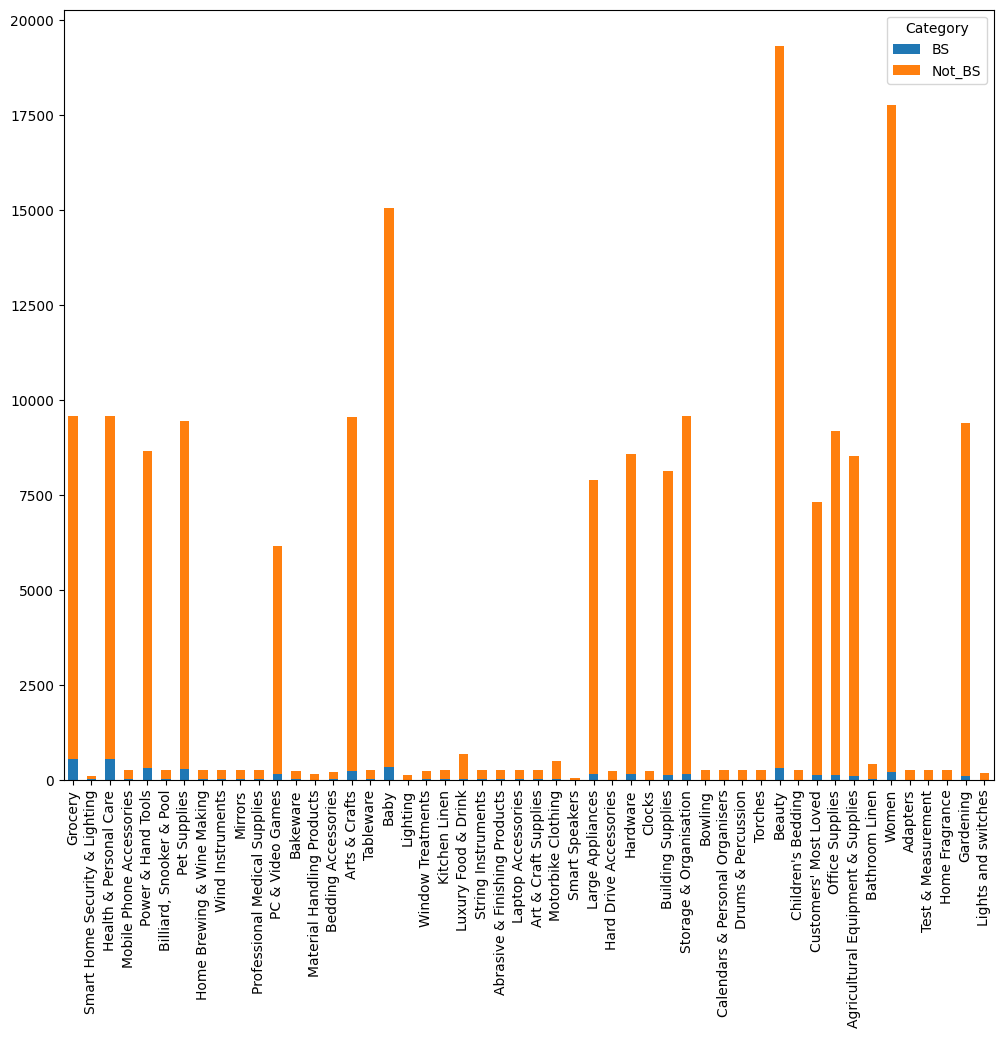

In [13]:
category_best_seller_crosstab_percent[["BS", "Not_BS"]].head(50).plot.bar(stacked=True, figsize=(12, 10))
plt.show()

## Part 2: Exploring Product Prices and Ratings Across Categories and Brands

*Objective*: Investigate how different product categories influence product prices.

*Preliminary Step*: Remove outliers in product prices.
For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.

1. Use a violin plot to visualize the distribution of ```price``` across different product ```categories```. Filter out the top 20 categories based on count for better visualization.
2. Which product category tends to have the highest median price? Don't filter here by top categories.
3. Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
4. Which product category commands the highest average price? Don't filter here by top categories.
5. Visualize the distribution of product ```ratings``` based on their ```category``` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
6. Which category tends to receive the highest median rating from customers? Don't filter here by top categories.


In [14]:
top_20_cat: pd.Series = df.category.value_counts().index.tolist()[:20]
display(top_20_cat)

['Sports & Outdoors',
 'Beauty',
 'Handmade Clothing, Shoes & Accessories',
 'Bath & Body',
 'Birthday Gifts',
 'Manicure & Pedicure Products',
 'Skin Care',
 'Make-up',
 'Hair Care',
 'Fragrances',
 'Handmade Gifts',
 'Handmade Home Décor',
 'Luggage and travel gear',
 'Handmade Jewellery',
 'Handmade Artwork',
 'Women',
 'Handmade Home & Kitchen Products',
 'Handmade Kitchen & Dining',
 'Men',
 'Baby']

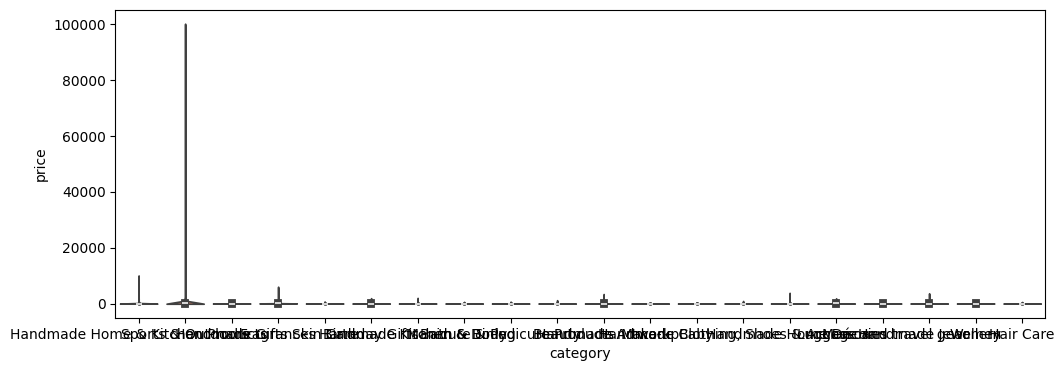

In [15]:
plt.figure(figsize=(12, 4))
sns.violinplot(
    data=df[(df.category.isin(top_20_cat))],
    x="category",
    y="price",
    hue="category"
)
plt.show()

Because of strong outliers in price, and the many categories, this visualization does not really help. Let's try with less categories and a defined price range.

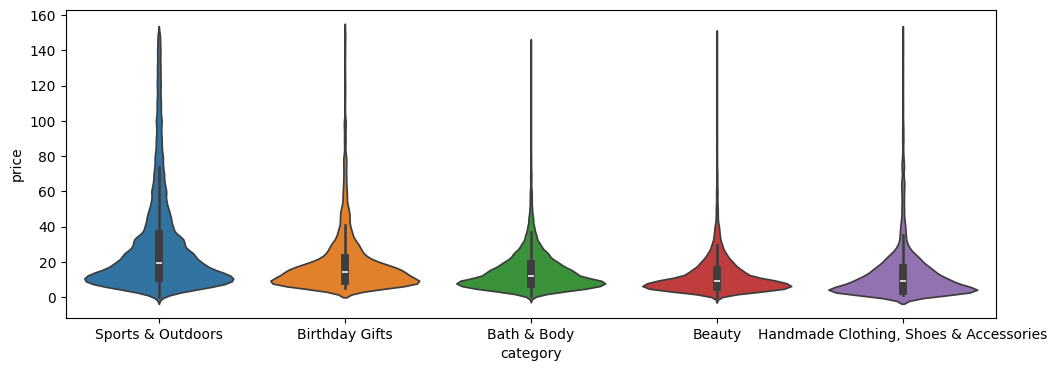

In [16]:
plt.figure(figsize=(12, 4))
sns.violinplot(
    data=df[(df.category.isin(top_20_cat[:5])) & (df.price < 150)],
    x="category",
    y="price",
    hue="category"
)
plt.show()

In [17]:
median_price_by_cat: pd.Series = df[["category", "price"]].groupby("category").median().sort_values("price", ascending=False)
median_price_by_cat.head()

,price
category,
Laptops,1042.725
Desktop PCs,810.400
Snowboards,366.725
Home Audio Record Players,326.080
3D Printers,319.000


```Laptops``` is the category with highest median price.

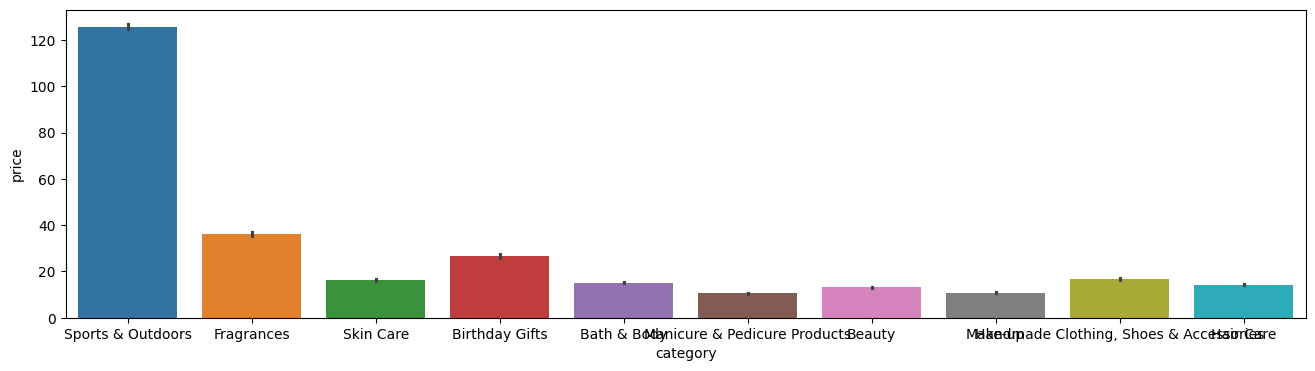

In [18]:
plt.figure(figsize=(16, 4))
sns.barplot(
    data=df[df.category.isin(top_20_cat[:10])],
    x="category",
    y="price",
    hue="category",
)
plt.show()

In [19]:
avg_price_by_cat: pd.Series = df[["category", "price"]].groupby("category").mean().sort_values("price", ascending=False)
avg_price_by_cat.head()

,price
category,
Laptops,1087.987827
3D Printers,1018.036129
Desktop PCs,926.816064
Home Office Furniture,622.135898
Test & Measurement,559.382973


Again, ```Laptops``` is the category with highest average price.

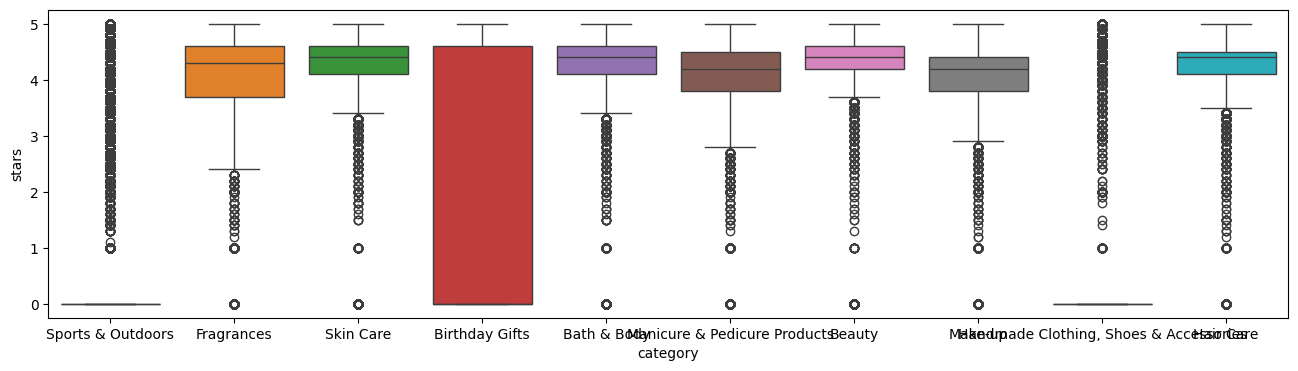

In [20]:
plt.figure(figsize=(16, 4))
sns.boxplot(
    data=df[df.category.isin(top_20_cat[:10])],
    x="category",
    y="stars",
    hue="category",
)
plt.show()

In [21]:
median_rating_by_cat: pd.Series = df[["category", "stars"]].groupby("category").median().sort_values("stars", ascending=False)
median_rating_by_cat.head()

,stars
category,
Computer Memory,4.7
Hobbies,4.6
"Beer, Wine & Spirits",4.6
Laptop Accessories,4.6
Kids' Play Figures,4.6


```Computer memory``` is the category with highest median rating.

## Part 3: Investigating the Interplay Between Product Prices and Ratings

*Objective*: Analyze how product ratings (```stars```) correlate with product prices.

1. Calculate the correlation coefficient between ```price``` and ```stars```.
2. Is there a significant correlation between product price and its rating?
3. Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
4. Use a correlation heatmap to visualize correlations between all numerical variables.
5. Examine if product prices typically follow a normal distribution using a QQ plot.

In [22]:
pearson_r: float = df.price.corr(df.stars, method="pearson").__round__(2)
spearman_p: float = df.price.corr(df.stars, method="spearman").__round__(2)

print("Pearson correlation:", pearson_r)
print("Spearman correlation:", spearman_p)

Pearson correlation: -0.12
Spearman correlation: -0.13


According to neither correlation measure (Pearson and Spearman) there is a correlation between ```price``` and ```stars```, whether linear or monotonic. The negative value may even indicate a negative correlation, but the association is too weak anyway.

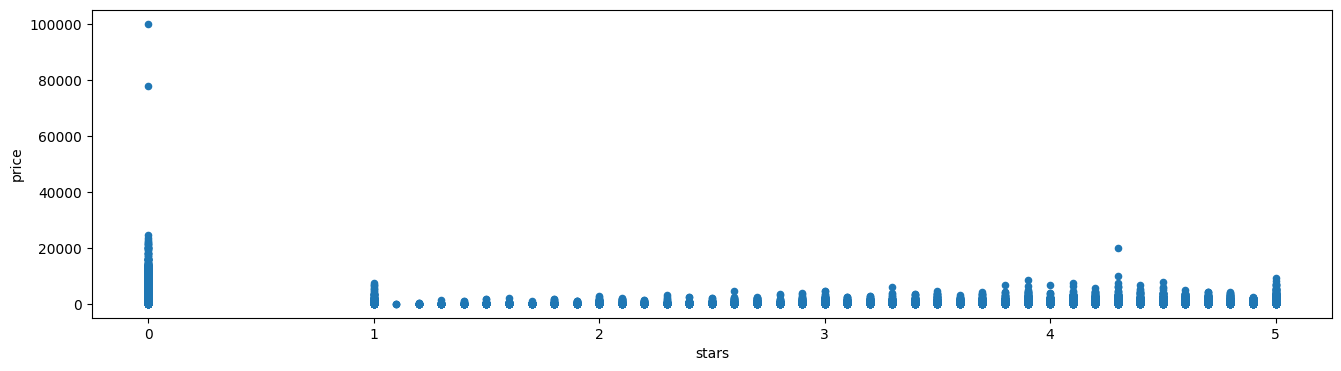

In [23]:
df.plot.scatter(x="stars", y="price", figsize=(16, 4))
plt.show()

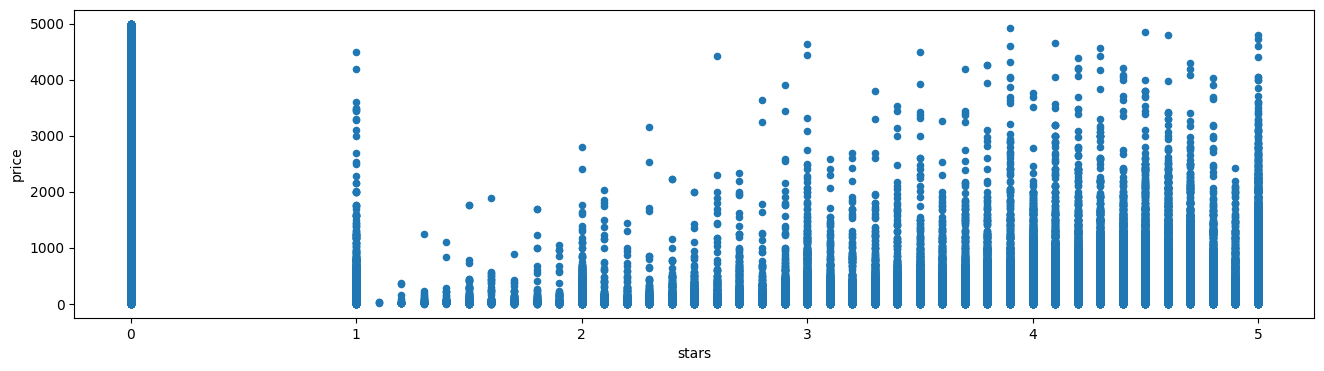

In [24]:
df[df.price < 5000].plot.scatter(x="stars", y="price", figsize=(16, 4)) # filter outliers for better scale
plt.show()

From the scatterplot too we can see that there doesn't seem to be any particular relationship between price and rating.

In [25]:
num_var: pd.DataFrame = df.select_dtypes("number").drop("uid", axis=1)

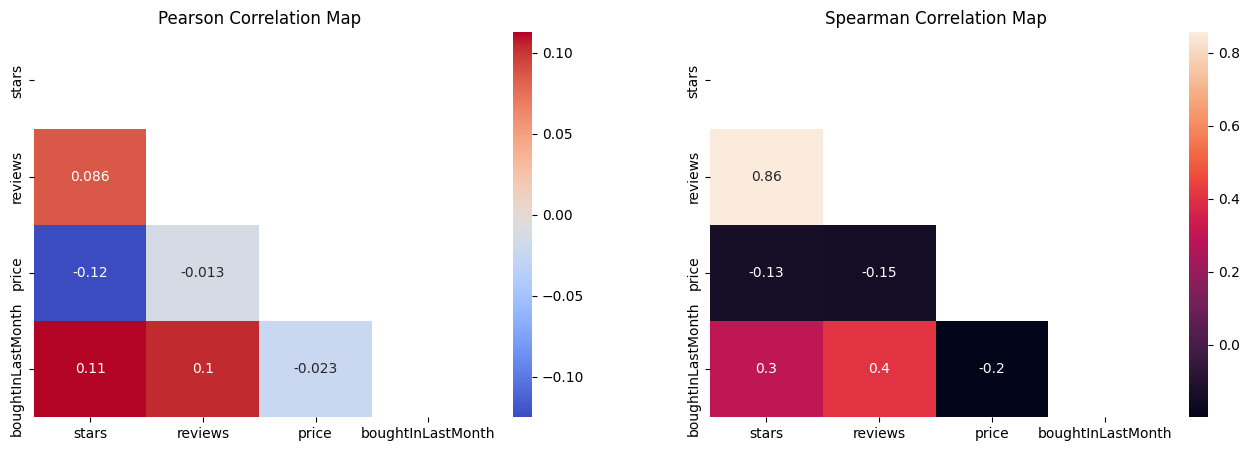

In [26]:
correlation_matrix_pearson = num_var.corr(method="pearson")
correlation_matrix_spearman = num_var.corr(method="spearman")

mask_pearson= np.triu(np.ones_like(correlation_matrix_pearson, dtype=bool))
mask_spearman= np.triu(np.ones_like(correlation_matrix_spearman, dtype=bool))

_, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

# Pearson matrix
sns.heatmap(
    data=correlation_matrix_pearson,
    mask=mask_pearson,
    annot=True,
    cmap="coolwarm",
    ax=axs[0],
).set_title("Pearson Correlation Map")

# Spearman matrix
sns.heatmap(
    data=correlation_matrix_spearman,
    mask=mask_spearman,
    annot=True,
    ax=axs[1]
).set_title("Spearman Correlation Map")

plt.show()

From the matrices we can conclude: the is no linear correlation among the numeric variables of this dataset (Pearson matrix), but there are some monotonic correlations (Spearman matrix). There is a strong monotonic correlation between stars and reviews, suggesting that as the rating grows higher, so do the reviews left (though not linearly, to keep in mind). We can observe a weaker correlation of this kind also between reviews and recently bought items, and between this latter and rating. This can give us some minor hints into customer behavior, such as that customers leaving higher ratings are more likely to leave product reviews too. At the same time, it shows that more recently sold items may have some more ratings/reviews than older items. This could be indicative of a change in customer behavior, i.e. as time progresses, customers are leaving more reviews and ratings. This is a speculative obeservation, but worth noting.

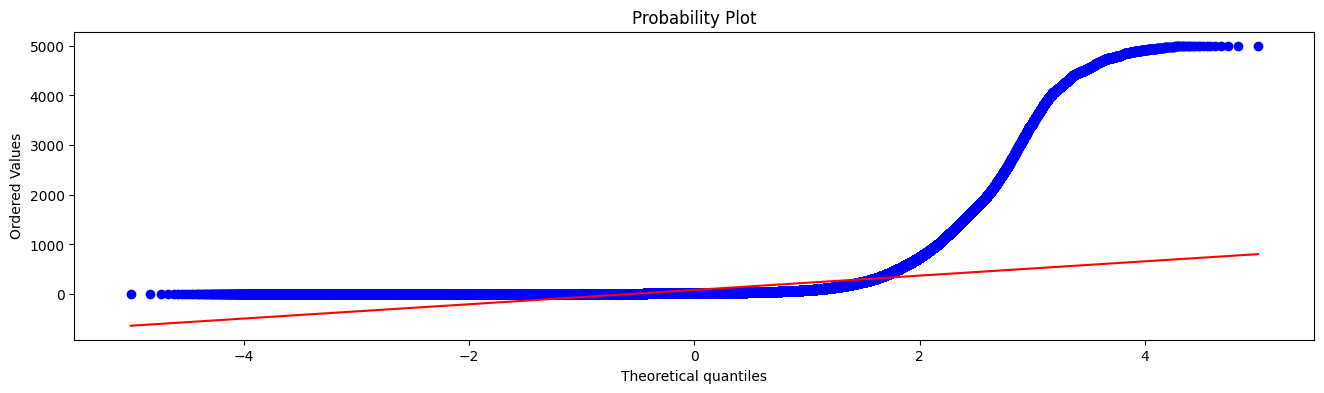

In [27]:
plt.figure(figsize=(16, 4))
stats.probplot(df.price[df.price < 5000], dist="norm", plot=plt) # Filter out price outliers for improved visualization
plt.show()

It is quite evident that product prices are not following a normal distribution.

## 